# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
!pip install sastrawi

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import joblib
from collections import Counter
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [9]:
dir = "/content/datasetUMPOHoax.csv"

df = pd.read_csv(dir)
df.head()

,topik,keyword,tweet,gambar,url,label
0,Air Garam,Air garam sumber energi,Mahasiswa ITS buat pembangkit listrik dari kol...,NaN,https://twitter.com/Klik_iT_indo/status/370802...,hoax
1,Air Garam,Air garam sumber energi,Lampu Dengan Sumber Energi Air Garam Ini Berpo...,NaN,https://twitter.com/Robin_nugraha/status/62854...,hoax
2,Air Garam,Air garam sumber energi,#didUknow Lampu LED yang menggunakan air dan g...,NaN,https://twitter.com/SerbaTauID/status/24731045...,hoax
3,Air Garam,Air garam sumber energi,#tekno Lampu Dengan Sumber Energi Air Garam In...,NaN,https://twitter.com/elrafa_agba/status/6285494...,hoax
4,Air Garam,Air garam sumber energi,"Green House,lampu darurat dg sumber energi gar...",NaN,https://twitter.com/HisenseID/status/761396317...,hoax


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   topik    3522 non-null   object
 1   keyword  3547 non-null   object
 2   tweet    4599 non-null   object
 3   gambar   87 non-null     object
 4   url      4611 non-null   object
 5   label    4617 non-null   object
dtypes: object(6)
memory usage: 216.6+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [11]:
#Cek missing value
df_missing = df.isna().sum()

#Cek duplicate
df_duplicate = df.duplicated().sum()

print(f'Jumlah missing value\n{df_missing}')
print(f'Jumlah duplicate\n{df_duplicate}')

Jumlah missing value
topik      1095
keyword    1070
tweet        18
gambar     4530
url           6
label         0
dtype: int64
Jumlah duplicate
6


In [12]:
#Distribusi label
df['label'].value_counts()

,count
label,
hoax,3042
?,845
valid,730


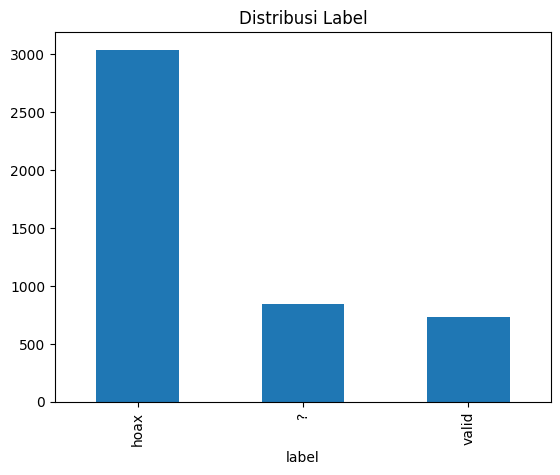

In [13]:
plt.title('Distribusi Label')
df['label'].value_counts().plot(kind='bar')
plt.show()

In [14]:
#Panjang text
df['text_length'] = df['tweet'].astype(str).apply(len)
df['text_length'].describe()

,text_length
count,4617.000000
mean,141.956465
std,75.371472
min,3.000000
25%,85.000000
50%,128.000000
75%,187.000000
max,804.000000


In [15]:
#Jumlah kata pertext
df['word_count'] = df['tweet'].apply(lambda x: len(str(x).split()))

df['word_count'].describe()

,word_count
count,4617.000000
mean,18.965345
std,10.604727
min,1.000000
25%,11.000000
50%,16.000000
75%,24.000000
max,123.000000


In [16]:
#Analisis berdasarkan label
df.groupby('label')['text_length'].mean()
df.groupby('label')['word_count'].mean()

,word_count
label,
?,18.691124
hoax,18.670283
valid,20.512329


In [17]:
#Kata yang sering muncul
all_words = ' '.join(df['tweet'].astype(str)).split()
Counter(all_words).most_common(20)

[('dan', 1060),
 ('di', 1028),
 ('yang', 971),
 ('untuk', 629),
 ('yg', 561),
 ('bisa', 512),
 ('dari', 458),
 ('ini', 387),
 ('itu', 374),
 ('ada', 374),
 ('dengan', 349),
 ('tidak', 290),
 ('makan', 289),
 ('air', 263),
 ('dapat', 260),
 ('menyebabkan', 253),
 (':', 238),
 ('manfaat', 238),
 ('mengandung', 235),
 ('Manfaat', 235)]

In [18]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
hoax,65.886940
?,18.301928
valid,15.811133


In [19]:
df[df['tweet'].str.strip() == ""]
df[df['word_count'] < 3]

,topik,keyword,tweet,gambar,url,label,text_length,word_count
789,NaN,NaN,02/,NaN,https://twitter.com/IlhamTsaqofi/status/121226...,?,3,1
990,NaN,NaN,Bumi datar,NaN,https://twitter.com/musangkertas/status/142271...,hoax,10,2
1037,Jantung Lemah,Jantung lemah tangan berkeringat,NaN,NaN,https://twitter.com/calonidamanibu/status/1330...,?,3,1
1714,kacang,kacang menyebabkan asam urat,https://twitter.com/Marthasi_love/status/12643...,NaN,https://twitter.com/Marthasi_love/status/12643...,?,59,1
2028,Oreo,Oreo berbahaya,https://twitter.com/Juwanda_Jun/status/3923093...,NaN,https://twitter.com/KicauanUnik/status/1565594...,hoax,57,1
2784,Temulawak,TEMULAWAK PENAMBAH NAFSU MAKAN,NaN,Temulawak Menambah Nafu Makan,https://twitter.com/timescoid/status/119478686...,valid,3,1
2791,tangan berkeringat,tangan berkeringat tanda jantung lemah,NaN,TAK SELAMANYA TANGAN BERKERINGAT TANDA JANTUNG...,https://twitter.com/enervi_id/status/591092455...,?,3,1
2804,BEM UI,kritik BEM UI kepada pak jokowi,NaN,Bem UI 2021,https://twitter.com/Okihita/status/14098650468...,valid,3,1
2814,makanan pedas,makanan pedas dapat menyebabkan usus buntu,NaN,"RUMAH SAKIT ""JIH"" MAKANAN PEDAS, BIKIN USUS BU...",https://twitter.com/RUMAHSAKITJIH/status/10905...,?,3,1
2867,lidah buaya,lidah buaya bagus untuk rambut,NaN,MANFAAT LIDAH BUAYA UNTUK RAMBUT,https://twitter.com/TRANSTV_CORP/status/119879...,valid,3,1


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [20]:
columns_to_drop = ['topik', 'keyword', 'url', 'gambar', 'text_length', 'word_count']
df_drop_columns = df.drop(columns=columns_to_drop)

df_drop_columns.head()

,tweet,label
0,Mahasiswa ITS buat pembangkit listrik dari kol...,hoax
1,Lampu Dengan Sumber Energi Air Garam Ini Berpo...,hoax
2,#didUknow Lampu LED yang menggunakan air dan g...,hoax
3,#tekno Lampu Dengan Sumber Energi Air Garam In...,hoax
4,"Green House,lampu darurat dg sumber energi gar...",hoax


In [21]:
df_drop_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   4599 non-null   object
 1   label   4617 non-null   object
dtypes: object(2)
memory usage: 72.3+ KB


In [22]:
#Handle missing value
df_clean_missing_value = df_drop_columns.dropna()

In [23]:
#Handel duplicate data
df_clean_duplicate = df_clean_missing_value.drop_duplicates()

In [24]:
df_clean_duplicate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4544 entries, 0 to 4616
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   4544 non-null   object
 1   label   4544 non-null   object
dtypes: object(2)
memory usage: 106.5+ KB


# **6. Clean Text**

In [25]:
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# Fungsi cleaning
def clean_text(text):
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # Tambahkan baris ini untuk mengganti 'yg' dengan 'yang'
    text = text.replace('yg', 'yang')

    # 2. Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)

    # 4. Hapus angka
    text = re.sub(r'\d+', '', text)

    # 5. Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Hapus whitespace berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # 7. Tokenisasi
    tokens = text.split()

    # 8. Hapus stopwords
    tokens = [word for word in tokens if word not in stopwords]

    # 9. Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    return ' '.join(tokens)

# Terapkan ke kolom teks
df_clean_duplicate['clean_text'] = df_clean_duplicate['tweet'].apply(clean_text)

# Lihat hasil
df_clean_duplicate[['tweet', 'clean_text']].head()

/tmp/ipykernel_1980/2822098826.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_duplicate['clean_text'] = df_clean_duplicate['tweet'].apply(clean_text)


,tweet,clean_text
0,Mahasiswa ITS buat pembangkit listrik dari kol...,mahasiswa its buat bangkit listrik kolam air g...
1,Lampu Dengan Sumber Energi Air Garam Ini Berpo...,lampu sumber energi air garam potensi jadi cha...
2,#didUknow Lampu LED yang menggunakan air dan g...,lampu led guna air garam sumber listrik belaka...
3,#tekno Lampu Dengan Sumber Energi Air Garam In...,lampu sumber energi air garam potensi jadi cha...
4,"Green House,lampu darurat dg sumber energi gar...",green houselampu darurat dg sumber energi gara...


In [27]:
all_words = ' '.join(df_clean_duplicate['clean_text']).split()
Counter(all_words).most_common(20)

[('manfaat', 589),
 ('makan', 560),
 ('sebab', 468),
 ('kandung', 439),
 ('vaksin', 437),
 ('jadi', 435),
 ('bahaya', 434),
 ('covid', 416),
 ('air', 412),
 ('sehat', 394),
 ('minum', 350),
 ('buat', 325),
 ('banyak', 309),
 ('kanker', 294),
 ('obat', 285),
 ('nyata', 250),
 ('benar', 248),
 ('sakit', 241),
 ('virus', 239),
 ('lebih', 227)]

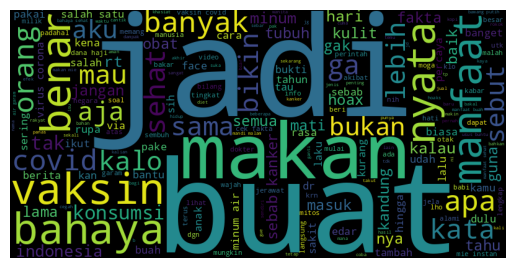

In [29]:
wordcloud = WordCloud(width=800, height=400).generate(' '.join(df_clean_duplicate['clean_text']))

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [30]:
df_clean_duplicate.head()

,tweet,label,clean_text
0,Mahasiswa ITS buat pembangkit listrik dari kol...,hoax,mahasiswa its buat bangkit listrik kolam air g...
1,Lampu Dengan Sumber Energi Air Garam Ini Berpo...,hoax,lampu sumber energi air garam potensi jadi cha...
2,#didUknow Lampu LED yang menggunakan air dan g...,hoax,lampu led guna air garam sumber listrik belaka...
3,#tekno Lampu Dengan Sumber Energi Air Garam In...,hoax,lampu sumber energi air garam potensi jadi cha...
4,"Green House,lampu darurat dg sumber energi gar...",hoax,green houselampu darurat dg sumber energi gara...


In [33]:
joblib.dump(df_clean_duplicate, 'data_clean.csv')

['data_clean.csv']